# Latent geometry on data we can actually see\nOn 8 by 8 digits the code space is easy to plot but the data is not. Here the data is two- or three-dimensional, so the encoder, the decoder, and the samples can all be drawn in the same picture.

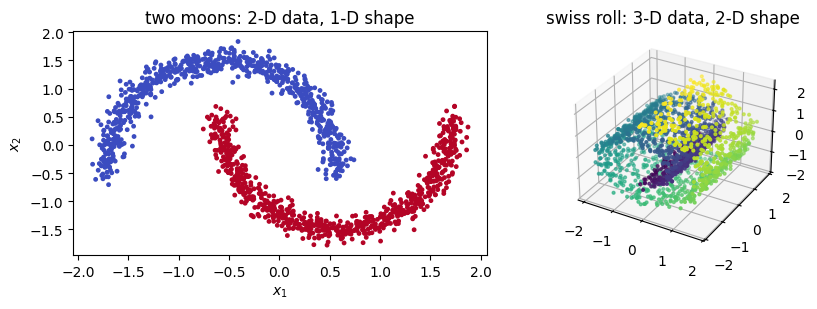

In [1]:
import numpy as np, matplotlib.pyplot as plt, torch
from torch import nn
from sklearn.datasets import make_moons, make_swiss_roll

torch.manual_seed(26520); np.random.seed(26520)

moons_raw, moons_label = make_moons(n_samples=1500, noise=0.06, random_state=26520)
moons = torch.tensor((moons_raw - moons_raw.mean(0)) / moons_raw.std(0), dtype=torch.float32)

roll_raw, roll_position = make_swiss_roll(n_samples=2000, noise=0.4, random_state=26520)
roll = torch.tensor((roll_raw - roll_raw.mean(0)) / roll_raw.std(0), dtype=torch.float32)

fig = plt.figure(figsize=(9, 3.2))
left = fig.add_subplot(1, 2, 1)
left.scatter(moons[:, 0], moons[:, 1], c=moons_label, cmap='coolwarm', s=6)
left.set(title='two moons: 2-D data, 1-D shape', xlabel='$x_1$', ylabel='$x_2$')
right = fig.add_subplot(1, 2, 2, projection='3d')
right.scatter(roll[:, 0], roll[:, 1], roll[:, 2], c=roll_position, cmap='viridis', s=4)
right.set(title='swiss roll: 3-D data, 2-D shape')
plt.tight_layout(); plt.show()

## A VAE for continuous data\nA Gaussian decoder with fixed $\\sigma$ makes the reconstruction term a scaled squared error, which is the right likelihood for coordinates rather than pixels.

In [2]:
class GaussianVAE(nn.Module):
    """Gaussian encoder and Gaussian decoder with a fixed observation variance."""
    def __init__(self, dim, latent, hidden=64):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh())
        self.mean = nn.Linear(hidden, latent)
        self.log_variance = nn.Linear(hidden, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.Tanh(),
                                     nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, dim))

    def encode(self, x):
        h = self.body(x)
        return self.mean(h), self.log_variance(h)

    def forward(self, x):
        mean, log_variance = self.encode(x)
        code = mean + torch.exp(0.5 * log_variance) * torch.randn_like(mean)
        return self.decoder(code), mean, log_variance


def fit(data, latent, beta=1.0, sigma=0.15, epochs=600, lr=3e-3, batch=256, seed=26520):
    """Gaussian likelihood with fixed sigma: reconstruction is scaled squared error."""
    torch.manual_seed(seed)
    model = GaussianVAE(dim=data.shape[1], latent=latent)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    generator = torch.Generator().manual_seed(seed)
    trace = []
    for _ in range(epochs):
        order = torch.randperm(len(data), generator=generator)
        for start in range(0, len(data), batch):
            xb = data[order[start:start + batch]]
            rebuilt, mean, log_variance = model(xb)
            reconstruction = ((xb - rebuilt) ** 2).sum(dim=1).mean() / (2 * sigma ** 2)
            divergence = (-0.5 * (1 + log_variance - mean ** 2 - log_variance.exp())).sum(dim=1).mean()
            optimizer.zero_grad(); (reconstruction + beta * divergence).backward(); optimizer.step()
        trace.append((reconstruction.item(), divergence.item()))
    return model.eval(), np.array(trace)

## One latent coordinate for the moons\nThe data is two-dimensional but nearly one-dimensional in shape. A code of size one asks the model to lay both arcs along a single line.

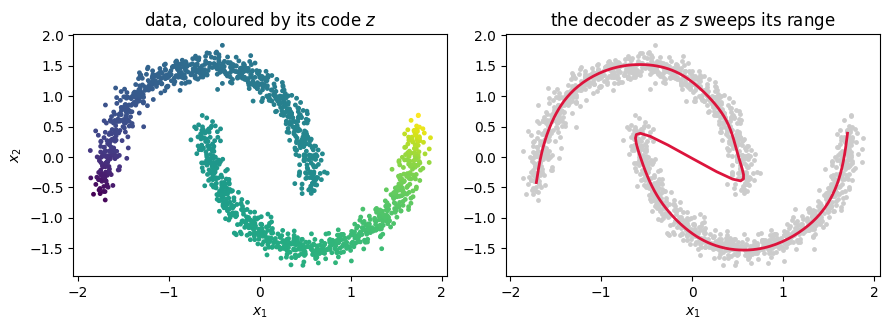

A one-dimensional code has to place both moons on a single curve.
Watch where the curve jumps between them: that gap is what the model cannot represent.


In [3]:
moons_model, moons_trace = fit(moons, latent=1, beta=1.0)

with torch.no_grad():
    codes, _ = moons_model.encode(moons)
    line = torch.linspace(codes.min(), codes.max(), 300).unsqueeze(1)
    curve = moons_model.decoder(line).numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].scatter(moons[:, 0], moons[:, 1], c=codes.squeeze(), cmap='viridis', s=6)
axes[0].set(title='data, coloured by its code $z$', xlabel='$x_1$', ylabel='$x_2$')
axes[1].scatter(moons[:, 0], moons[:, 1], color='0.8', s=6)
axes[1].plot(curve[:, 0], curve[:, 1], color='crimson', lw=2)
axes[1].set(title='the decoder as $z$ sweeps its range', xlabel='$x_1$')
plt.tight_layout(); plt.show()

print('A one-dimensional code has to place both moons on a single curve.')
print('Watch where the curve jumps between them: that gap is what the model cannot represent.')

## Two latent coordinates for the swiss roll\nThree-dimensional data on a two-dimensional sheet. If the encoder has found the sheet, the colours in the code plot should vary smoothly.

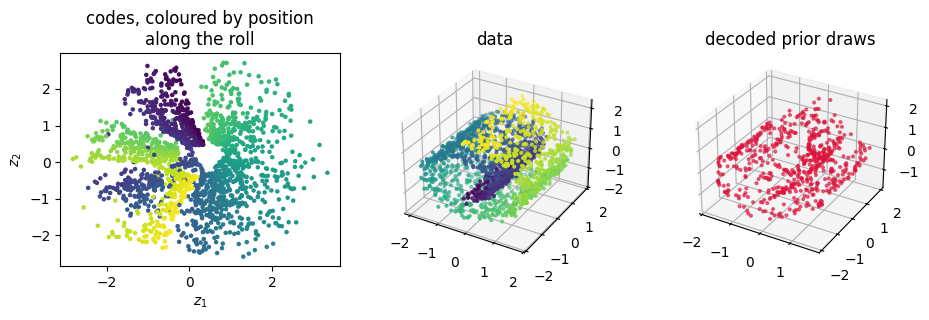

In [4]:
roll_model, roll_trace = fit(roll, latent=2, beta=1.0, epochs=800)

with torch.no_grad():
    roll_codes, _ = roll_model.encode(roll)
    drawn = roll_model.decoder(torch.randn(600, 2)).numpy()

fig = plt.figure(figsize=(9.5, 3.3))
first = fig.add_subplot(1, 3, 1)
first.scatter(roll_codes[:, 0], roll_codes[:, 1], c=roll_position, cmap='viridis', s=5)
first.set(title='codes, coloured by position\nalong the roll', xlabel='$z_1$', ylabel='$z_2$')
second = fig.add_subplot(1, 3, 2, projection='3d')
second.scatter(roll[:, 0], roll[:, 1], roll[:, 2], c=roll_position, cmap='viridis', s=4)
second.set(title='data')
third = fig.add_subplot(1, 3, 3, projection='3d')
third.scatter(drawn[:, 0], drawn[:, 1], drawn[:, 2], color='crimson', s=4, alpha=0.6)
third.set(title='decoded prior draws')
plt.tight_layout(); plt.show()

## The KL weight, seen directly\nOn the digits we had to read the KL per coordinate to see a collapse. Here the consequence is visible: the decoded prior draws stop covering the data.

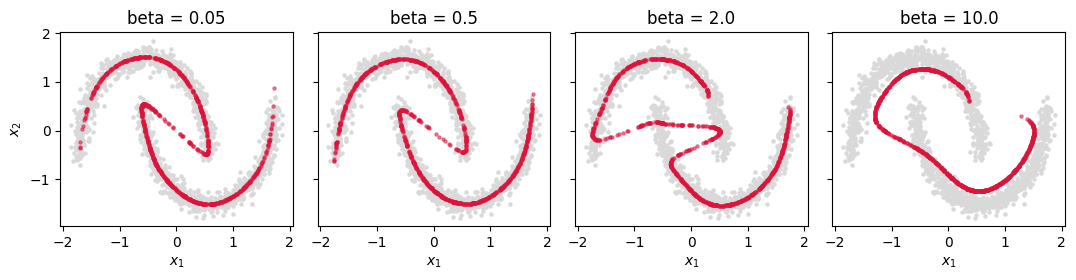

Grey: data. Red: decoded prior draws.
As beta grows the samples smooth out and stop following the two arcs: the code
is being charged for the detail that distinguishes them.


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9), sharex=True, sharey=True)
for ax, beta in zip(axes, [0.05, 0.5, 2.0, 10.0]):
    model, _ = fit(moons, latent=1, beta=beta, epochs=400)
    with torch.no_grad():
        code, _ = model.encode(moons)
        sampled = model.decoder(torch.randn(800, 1)).numpy()
    ax.scatter(moons[:, 0], moons[:, 1], color='0.85', s=5)
    ax.scatter(sampled[:, 0], sampled[:, 1], color='crimson', s=5, alpha=0.5)
    ax.set(title=f'beta = {beta}', xlabel='$x_1$')
axes[0].set_ylabel('$x_2$')
plt.tight_layout(); plt.show()

print('Grey: data. Red: decoded prior draws.')
print('As beta grows the samples smooth out and stop following the two arcs: the code')
print('is being charged for the detail that distinguishes them.')

## The same data with a discrete code\nReplacing the sampled code by a nearest-codebook lookup turns the model into something very close to the clustering of Lecture 15.

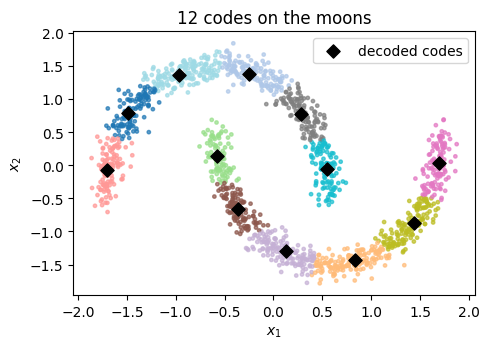

12 of 12 codes are in use.
Compare with K-means from Lecture 15: the picture is a partition, but the
boundaries are drawn in the encoder output space, not in the data space.


In [6]:
class VQ(nn.Module):
    def __init__(self, dim, codes, width=2, hidden=64):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, width))
        self.codebook = nn.Embedding(codes, width)
        self.codebook.weight.data.uniform_(-1, 1)
        self.decoder = nn.Sequential(nn.Linear(width, hidden), nn.Tanh(), nn.Linear(hidden, dim))

    def forward(self, x):
        z_e = self.encoder(x)
        index = torch.cdist(z_e, self.codebook.weight).argmin(dim=1)
        z_q = self.codebook(index)
        return self.decoder(z_e + (z_q - z_e).detach()), z_e, z_q, index


def fit_vq(data, codes, epochs=500, commitment=0.25, lr=3e-3, batch=256, seed=26520):
    torch.manual_seed(seed)
    model = VQ(dim=data.shape[1], codes=codes)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    generator = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        order = torch.randperm(len(data), generator=generator)
        for start in range(0, len(data), batch):
            xb = data[order[start:start + batch]]
            rebuilt, z_e, z_q, _ = model(xb)
            loss = (((xb - rebuilt) ** 2).sum(dim=1).mean()
                    + ((z_e.detach() - z_q) ** 2).sum(dim=1).mean()
                    + commitment * ((z_e - z_q.detach()) ** 2).sum(dim=1).mean())
            optimizer.zero_grad(); loss.backward(); optimizer.step()
    return model.eval()


vq = fit_vq(moons, codes=12)
with torch.no_grad():
    rebuilt, _, _, index = vq(moons)
    prototypes = vq.decoder(vq.codebook.weight).numpy()

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(moons[:, 0], moons[:, 1], c=index, cmap='tab20', s=6, alpha=0.7)
ax.scatter(prototypes[:, 0], prototypes[:, 1], color='black', marker='D', s=45, label='decoded codes')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='12 codes on the moons')
ax.legend(); plt.tight_layout(); plt.show()

print(f'{len(np.unique(index))} of 12 codes are in use.')
print('Compare with K-means from Lecture 15: the picture is a partition, but the')
print('boundaries are drawn in the encoder output space, not in the data space.')